In [78]:
import sys, os 
import numpy as np 
import pandas as pd
from src import utils, db, behavmatch, rsm
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%load_ext autoreload
%autoreload 2
from matplotlib import rcParams
default_font = 8
fs_title = 10
rcParams['font.size'] = default_font
rcParams['axes.titlesize'] = fs_title
from IPython.display import clear_output
from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
obj_path = Path(r"D:\mouseobj")
dfs_path = obj_path.joinpath(r"overall\last_training")

In [57]:
df_all = pd.read_csv(dfs_path.joinpath("trial_trial_rsm_summary_alltrials.csv"))
df_matched = pd.read_csv(dfs_path.joinpath("trial_trial_rsm_summary_matched.csv"))

In [58]:
df_iindex_trial = pd.concat([df_all, df_matched], ignore_index=True)

In [59]:
df_iindex_trial

,mouse,session,area,celltype,IntraA_prot,IntraB_prot,InterCat_prot,IntraA_nonprot,IntraB_nonprot,InterCat_nonprot
0,VG11,all rewarded before,V1,Pyr,0.219642,0.190431,-0.117548,0.044980,0.041535,0.003284
1,VG11,all rewarded before,V1,Int,0.208943,0.119765,-0.049830,0.056518,0.066701,0.039676
2,VG11,all rewarded before,medial,Pyr,0.154004,0.141455,-0.088136,0.041765,0.036376,0.001231
3,VG11,all rewarded before,medial,Int,0.075134,0.171422,-0.057195,0.038841,0.038577,0.023316
4,VG11,all rewarded before,lateral,Pyr,0.234195,0.210595,-0.135326,0.050929,0.047713,-0.006638
...,...,...,...,...,...,...,...,...,...,...
387,VGa9,last training (matched),medial,Int,0.264577,0.280003,-0.092199,0.145953,0.218026,-0.017456
388,VGa9,last training (matched),lateral,Pyr,0.239492,0.238610,-0.105071,0.061933,0.074089,-0.009105
389,VGa9,last training (matched),lateral,Int,0.327578,0.244686,-0.116188,0.072227,0.137931,-0.000790
390,VGa9,last training (matched),anterior,Pyr,0.176300,0.127840,-0.061498,0.035838,0.102274,-0.025604


In [60]:
df_iindex_trial = df_iindex_trial.assign(prot_distance = np.mean([df_iindex_trial['IntraA_prot'], df_iindex_trial['IntraB_prot']], axis=0)- df_iindex_trial['InterCat_prot'],
                        nonprot_distance = np.mean([df_iindex_trial['IntraA_nonprot'], df_iindex_trial['IntraB_nonprot']], axis=0) - df_iindex_trial['InterCat_nonprot'])

In [62]:
df_iindex_trial = df_iindex_trial.assign(ii_rsm = (df_iindex_trial["nonprot_distance"] / df_iindex_trial["prot_distance"] + 1e-6))

In [63]:
df_iindex_trial

,mouse,session,area,celltype,IntraA_prot,IntraB_prot,InterCat_prot,IntraA_nonprot,IntraB_nonprot,InterCat_nonprot,prot_distance,nonprot_distance,ii_rsm
0,VG11,all rewarded before,V1,Pyr,0.219642,0.190431,-0.117548,0.044980,0.041535,0.003284,0.322585,0.039974,0.123917
1,VG11,all rewarded before,V1,Int,0.208943,0.119765,-0.049830,0.056518,0.066701,0.039676,0.214184,0.021934,0.102407
2,VG11,all rewarded before,medial,Pyr,0.154004,0.141455,-0.088136,0.041765,0.036376,0.001231,0.235866,0.037840,0.160429
3,VG11,all rewarded before,medial,Int,0.075134,0.171422,-0.057195,0.038841,0.038577,0.023316,0.180473,0.015394,0.085297
4,VG11,all rewarded before,lateral,Pyr,0.234195,0.210595,-0.135326,0.050929,0.047713,-0.006638,0.357721,0.055959,0.156433
...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,VGa9,last training (matched),medial,Int,0.264577,0.280003,-0.092199,0.145953,0.218026,-0.017456,0.364489,0.199445,0.547193
388,VGa9,last training (matched),lateral,Pyr,0.239492,0.238610,-0.105071,0.061933,0.074089,-0.009105,0.344122,0.077116,0.224097
389,VGa9,last training (matched),lateral,Int,0.327578,0.244686,-0.116188,0.072227,0.137931,-0.000790,0.402320,0.105869,0.263147
390,VGa9,last training (matched),anterior,Pyr,0.176300,0.127840,-0.061498,0.035838,0.102274,-0.025604,0.213568,0.094660,0.443232


In [64]:
def get_feature_values(df: pd.DataFrame, area: str, celltype: str, session: str, feature: str) -> np.ndarray:
    a = df.query(f"session == '{session}'")
    b = a.query(f"area == '{area}' & celltype == '{celltype}'")
    feature_values= b[feature].values
    return feature_values

def get_feature_fromdf(feature_name: str, df: pd.DataFrame):
    sessions = ['first training', 'last training', 'last training (matched)']
    areas = ['V1', 'medial', 'lateral', 'anterior']
    celltype = ['Pyr', 'Int']
    nmice = 10
    f_dict = {}
    for sess in sessions: 
        fts = np.empty((nmice, len(areas), len(celltype)))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                ft = get_feature_values(df, area, ctype, sess, feature_name)
                #store values
                fts[:,ia,ic] = ft
        f_dict[sess] = fts
    df_no34 = df.query("mouse != 'VG34'")
    sessions = ['all rewarded before', 'all rewarded after']
    nmice = 9
    for sess in sessions: 
        fts = np.empty((nmice, len(areas), len(celltype)))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                ft = get_feature_values(df_no34, area, ctype, sess, feature_name)
                #store values
                fts[:,ia,ic] = ft
        f_dict[sess] = fts
    return f_dict   

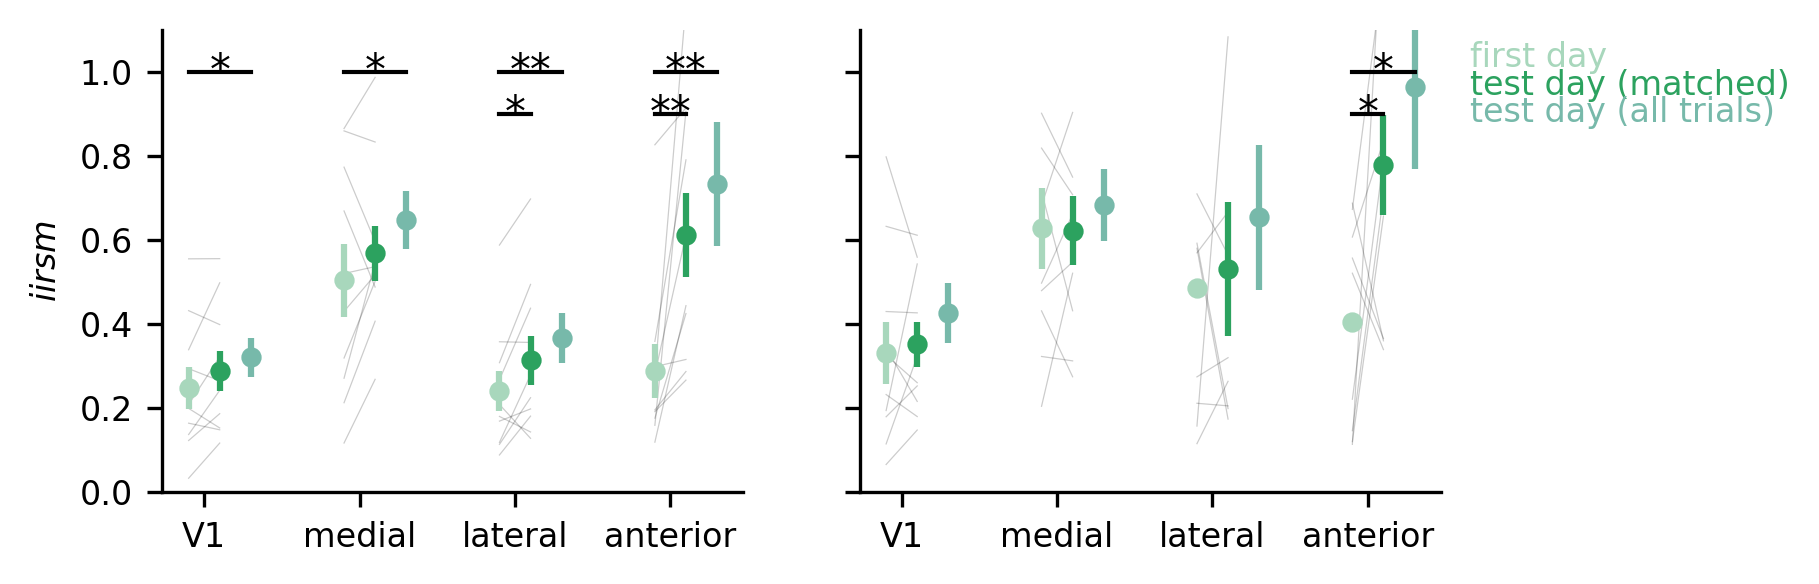

In [77]:
ii_rsm = get_feature_fromdf("ii_rsm", df_iindex_trial)
from src import fig1
gis_first =ii_rsm['first training']
gis_last = ii_rsm['last training']
gis_last_m = ii_rsm['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=1, alternative=("greater", "greater"), ylabel='$ii rsm$')
for a in ax.flatten():
    a.set_ylim(0,1.1)
sns.despine()

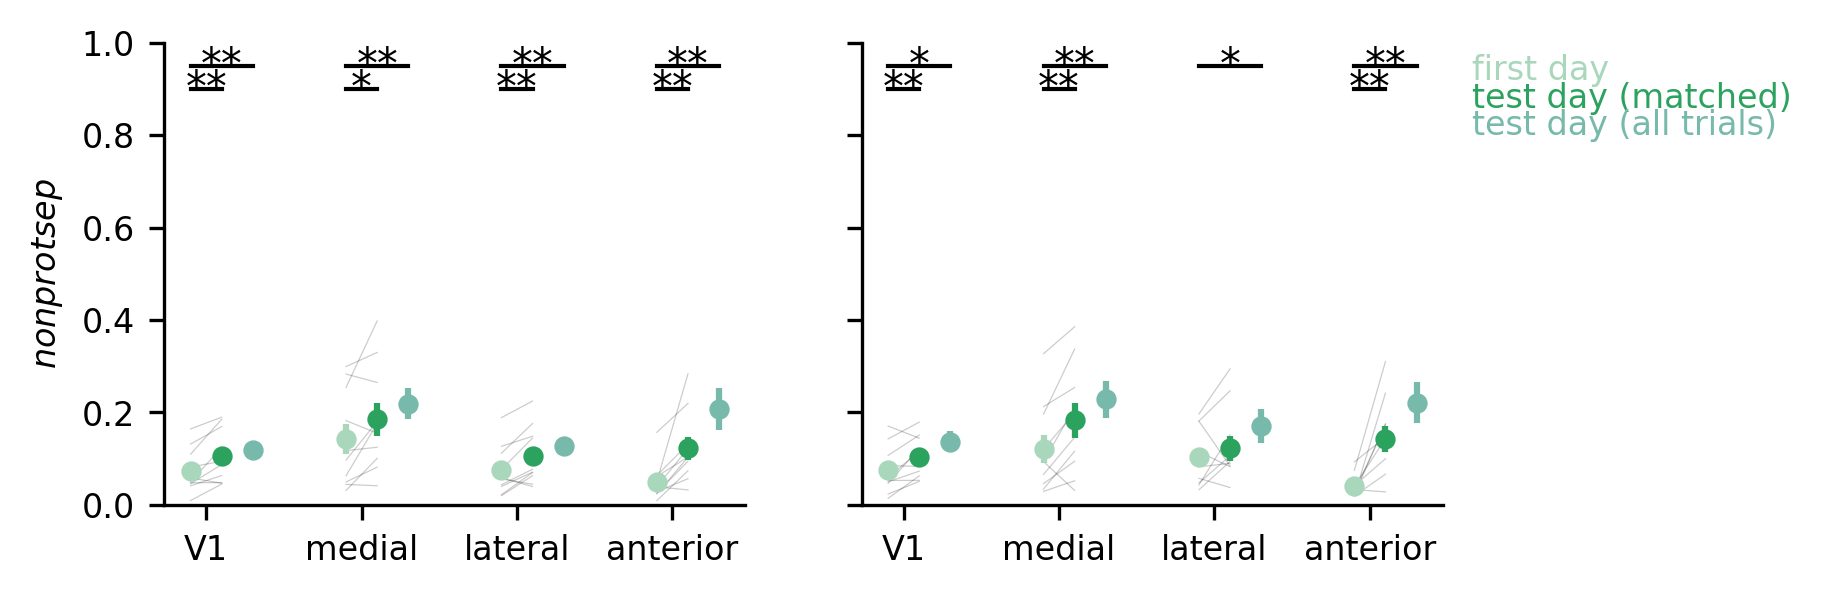

In [74]:
nonprot_distance = get_feature_fromdf("nonprot_distance", df_iindex_trial)
from src import fig1
gis_first = nonprot_distance['first training']
gis_last = nonprot_distance['last training']
gis_last_m = nonprot_distance['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=.95, alternative=("greater", "greater"), ylabel='$non prot sep$')
for a in ax.flatten():
    a.set_ylim(0,1)
sns.despine()

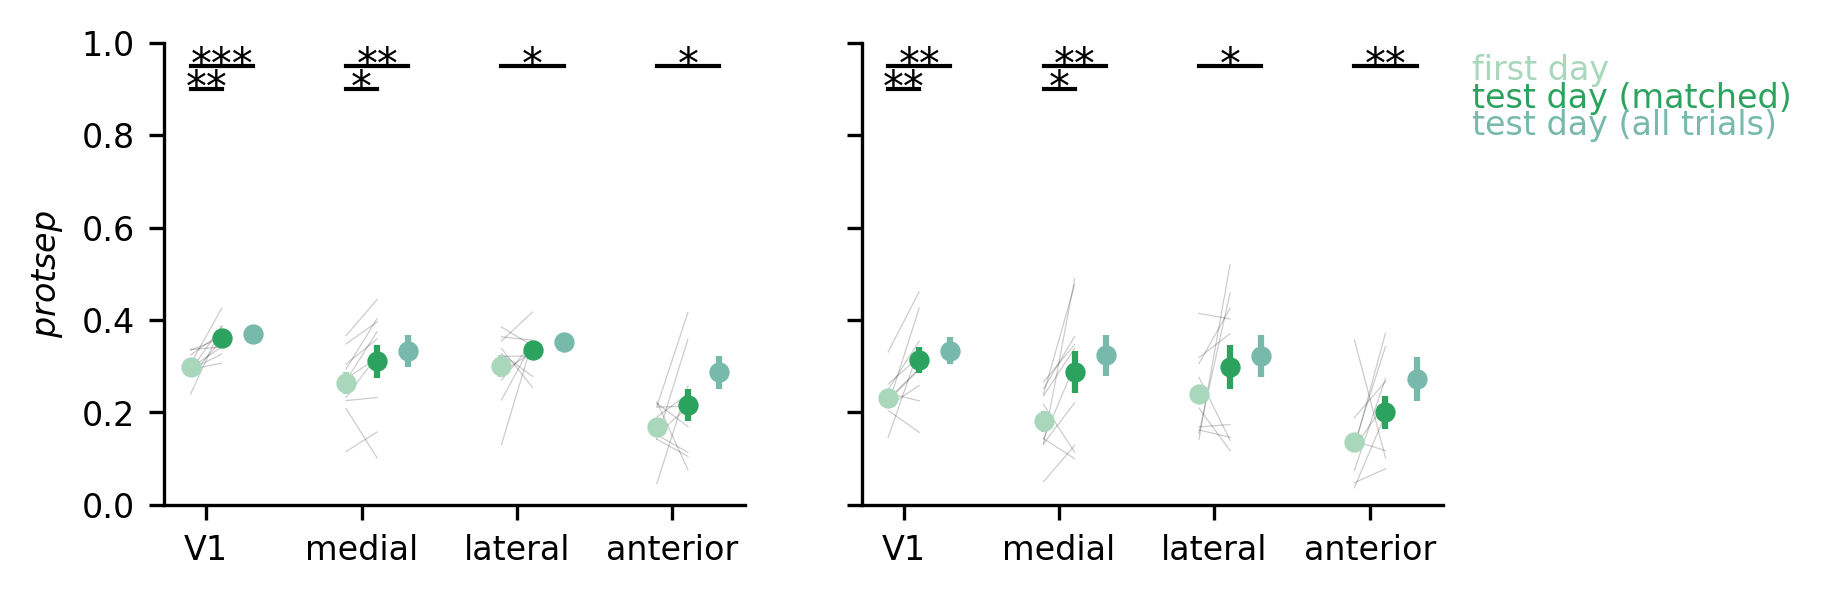

In [75]:
prot_distance = get_feature_fromdf("prot_distance", df_iindex_trial)
from src import fig1
gis_first = prot_distance['first training']
gis_last = prot_distance['last training']
gis_last_m = prot_distance['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=.95, alternative=("greater", "greater"), ylabel='$prot sep$')
for a in ax.flatten():
    a.set_ylim(0,1)
sns.despine()

In [79]:
working_dbase = db.get_sessions().query("recording == True")
working_dbase.loc[:, "name_round"] = working_dbase["mname"] + "_"+ working_dbase["round_id"].astype(str)
sessions = working_dbase["session"].unique()
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int'] 
nmice = working_dbase["name_round"].nunique()
nareas = len(areas)
ncelltypes = len(celltype)
n_sessions = len(sessions)
obj_path = Path(r"D:\mouseobj")

In [80]:
sessions_names = ['all rewarded before', 'first training', 'last training', 'last training (matched)', 'all rewarded after']

In [82]:
def dprime_cell(response, condition1, condition2, discrimination_region=(0,125), subpop=None):
    """
    Compute the d-prime for a single cell.
    """
    response = response[:,:,discrimination_region[0]:discrimination_region[1]].mean(2)
    r1 = response[:, condition1]
    r2 = response[:, condition2]
    if subpop is not None:
        r1 = r1[subpop]
        r2 = r2[subpop]
    # collect means and stds
    mu1 = r1.mean(1)
    mu2 = r2.mean(1)
    std1 = r1.std(1) + np.finfo(np.float64).tiny
    std2 = r2.std(1) + np.finfo(np.float64).tiny
    #compute the train dprime
    dp = 2 * ((mu1 - mu2) / (std1 + std2))
    return dp

def get_matched_trials(m):
    object_path = Path(r"D:\mouseobj")
    cbin = 3 
    name, datexp, blk = m.name, m.datexp, m.blk
    save_pth = object_path.joinpath(name,datexp,blk)
    protA = m.trial_dict["rewarded"]
    protB = m.trial_dict["non rewarded"]
    restA = m.trial_dict["rewarded test"]
    restB =  m.trial_dict["non rewarded test"]
    probs = np.load(save_pth.joinpath("probs.npy"), allow_pickle=True)
    prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
    rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
    m_rew = np.concatenate(prot_matched_trials[:,0]).astype(int)
    m_nrew = np.concatenate(prot_matched_trials[:,1]).astype(int)
    m_rew_test = np.concatenate(rest_matched_trials[:,0]).astype(int)
    m_nrew_test = np.concatenate(rest_matched_trials[:,1]).astype(int)
    trial_dict_matched = {"rewarded": m_rew,
                        "non rewarded": m_nrew,
                        "rewarded test": m_rew_test,
                        "non rewarded test": m_nrew_test}
    return trial_dict_matched

def select_neurons(m1, area: str, celltype:str, dprime = None, dptsh=95):
    ia = utils.get_region_idx(m1.iarea, area)
    assert celltype in ['Pyr', 'Int'], "celltype must be either 'Pyr' or 'Int'"
    selected_type = np.logical_not(m1.isred[:,0]).astype(bool) if celltype == 'Pyr' else m1.isred[:,0].astype(bool)
    if dprime is None:
        pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(m1.train_dp[ia*selected_type], tsh=dptsh) #tresh based on the area
    else:
        pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dprime[ia*selected_type], tsh=dptsh)
    prefer_r = (m1.train_dp>=pstv_tsh)
    prefer_nr = (m1.train_dp<=ngtv_tsh)
    area_prefer_r = prefer_r * ia * selected_type
    area_prefer_nr = prefer_nr * ia * selected_type
    return area_prefer_r, area_prefer_nr, selected_type, ia

In [83]:
rows = []
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
            dp = dprime_cell(m.interp_spks, t_dict["rewarded"][::2], t_dict["non rewarded"][::2], discrimination_region=(0,100))
            protA = t_dict["rewarded"][1::2]
            protB = t_dict["non rewarded"][1::2]
            restA = t_dict["rewarded test"]
            restB =  t_dict["non rewarded test"]
            t_dict_cv = {"rewarded": protA, "non rewarded": protB, "rewarded test": restA, "non rewarded test": restB}
            named = "trial_trial_rsm_dp_matched.npy"
        else:
            t_dict = m.trial_dict
            dp = dprime_cell(m.interp_spks, t_dict["rewarded"][::2], t_dict["non rewarded"][::2], discrimination_region=(0,100))
            protA = t_dict["rewarded"][1::2]
            protB = t_dict["non rewarded"][1::2]
            restA = t_dict["rewarded test"]
            restB =  t_dict["non rewarded test"]
            t_dict_cv = {"rewarded": protA, "non rewarded": protB, "rewarded test": restA, "non rewarded test": restB}
            named = "trial_trial_rsm_dp.npy"
        mask_B = m.frameselector['trial_type'].isin(['non rewarded', 'non rewarded test'])
        base = m.frameselector['istim'].astype('Int64') - 1  # zero-based
        m.frameselector['stim_id_matrix'] = np.where(~mask_B, base, base + 51)
        ntrials = m.interp_spks.shape[1]
        save_pth = obj_path.joinpath(name,datexp,blk)
        rsm_m = np.empty((ntrials, ntrials, nareas, ncelltypes))
        per_trial_resp = m.interp_spks[:, :, :100].mean(2)  # (neurons, trials)
        trials_per_stim = rsm.get_trials_per_stim(m)
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                select_r, select_nr, _, _ = select_neurons(m, area, ctype, dprime=dp, dptsh=95)
                selected_neurons = select_r + select_nr
                sig_neurons = per_trial_resp[selected_neurons, :]  # filter neurons
                sig_neurons = zscore(sig_neurons, axis=1, nan_policy='omit') #zscore across textures
                rsm_matrix = rsm.get_rsm_trial(sig_neurons)
                rsm_cleaned = rsm.clean_rsm_trial(rsm_matrix, sig_neurons, trials_per_stim)
                rsm_m[:,:,ia,ic] = rsm_cleaned
                #prot
                filtered_rsm_prot = rsm.filter_rsm(rsm_cleaned, t_dict_cv["rewarded"], t_dict_cv["non rewarded"])
                intraA_prot, intraB_prot, intercat_prot = rsm.compute_iindex_cond(filtered_rsm_prot, t_dict_cv["rewarded"])
                #nonprot
                filtered_rsm_nonprot = rsm.filter_rsm(rsm_cleaned, t_dict_cv["rewarded test"], t_dict_cv["non rewarded test"])
                intraA_nonprot, intraB_nonprot, intercat_nonprot = rsm.compute_iindex_cond(filtered_rsm_nonprot, t_dict_cv["rewarded test"])
                rows.append({
                    "mouse": name,
                    "session": sess,
                    "area": area,
                    "celltype": ctype,
                    "IntraA_prot": intraA_prot,
                    "IntraB_prot": intraB_prot,
                    "InterCat_prot": intercat_prot,
                    "IntraA_nonprot": intraA_nonprot,
                    "IntraB_nonprot": intraB_nonprot,
                    "InterCat_nonprot": intercat_nonprot
                })
        np.save(save_pth.joinpath(named), rsm_m)
    clear_output(wait=True)
df_iindex_trial_dptsh = pd.DataFrame(rows)
df_iindex_trial_dptsh.to_csv(obj_path.joinpath("overall","trial_trial_rsm_summary_all_dptsh.csv"), index=False)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\20

C:\Users\labadmin\AppData\Local\Temp\ipykernel_32676\3902923144.py:43: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sig_neurons = zscore(sig_neurons, axis=1, nan_policy='omit') #zscore across textures
C:\Users\labadmin\Documents\category-neural\src\rsm.py:168: RuntimeWarning: Mean of empty slice
  intraA = np.nanmean(rsm_filtered[:len(cond1), :len(cond1)])
C:\Users\labadmin\Documents\category-neural\src\rsm.py:169: RuntimeWarning: Mean of empty slice
  intraB = np.nanmean(rsm_filtered[len(cond1):, len(cond1):])
C:\Users\labadmin\Documents\category-neural\src\rsm.py:170: RuntimeWarning: Mean of empty slice
  intercat = np.nanmean(rsm_filtered[:len(cond1), len(cond1):])


Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG15\2024_11_01\3
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG21\2025_07_18\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG21\2025_08_08\2
Existing mouse objec

In [84]:
df_iindex_trial_dptsh = df_iindex_trial_dptsh.assign(prot_distance = np.mean([df_iindex_trial_dptsh['IntraA_prot'], df_iindex_trial_dptsh['IntraB_prot']], axis=0)- df_iindex_trial_dptsh['InterCat_prot'],
                        nonprot_distance = np.mean([df_iindex_trial_dptsh['IntraA_nonprot'], df_iindex_trial_dptsh['IntraB_nonprot']], axis=0) - df_iindex_trial_dptsh['InterCat_nonprot'])
df_iindex_trial_dptsh = df_iindex_trial_dptsh.assign(ii_rsm = (df_iindex_trial_dptsh["nonprot_distance"] / df_iindex_trial_dptsh["prot_distance"] + 1e-6))

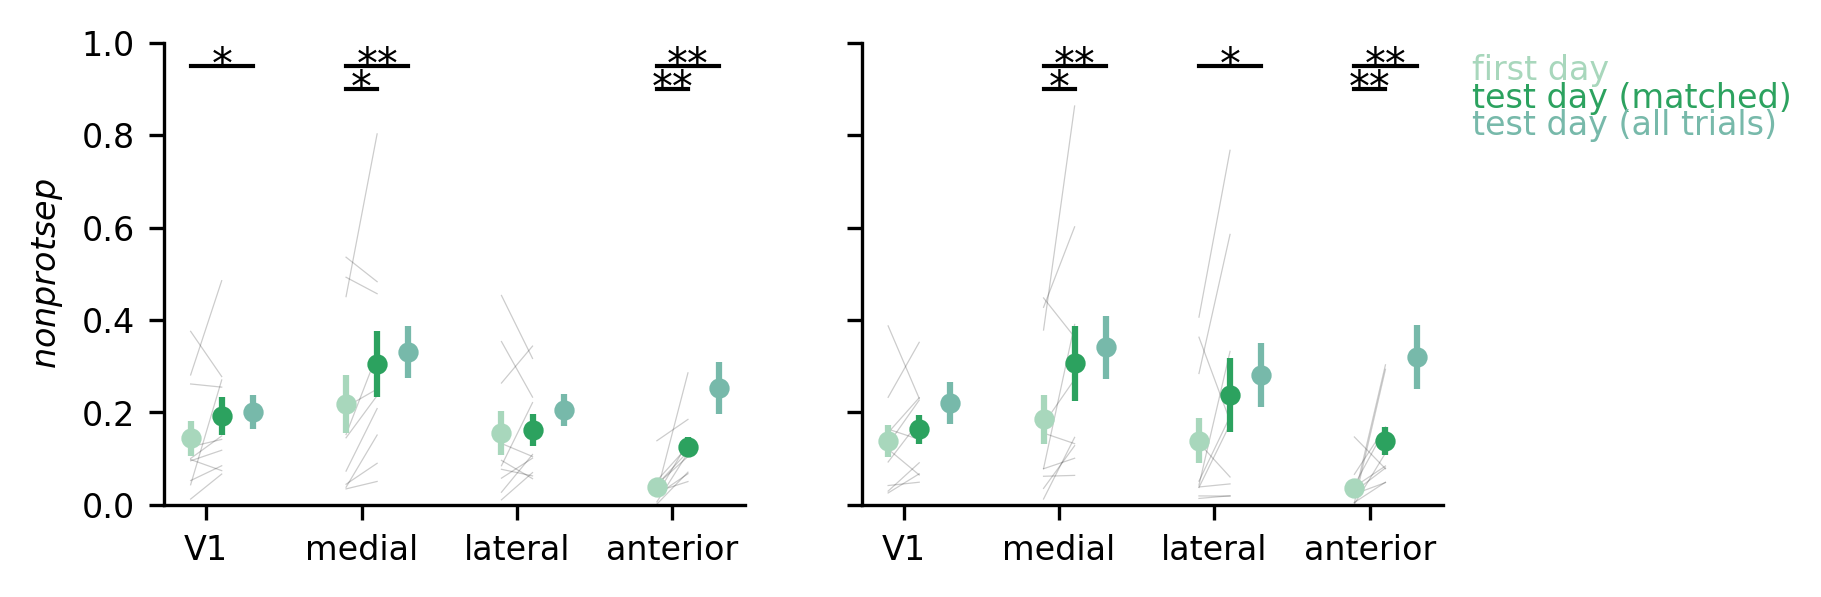

In [85]:
nonprot_distance = get_feature_fromdf("nonprot_distance", df_iindex_trial_dptsh)
from src import fig1
gis_first = nonprot_distance['first training']
gis_last = nonprot_distance['last training']
gis_last_m = nonprot_distance['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=.95, alternative=("greater", "greater"), ylabel='$non prot sep$')
for a in ax.flatten():
    a.set_ylim(0,1)
sns.despine()

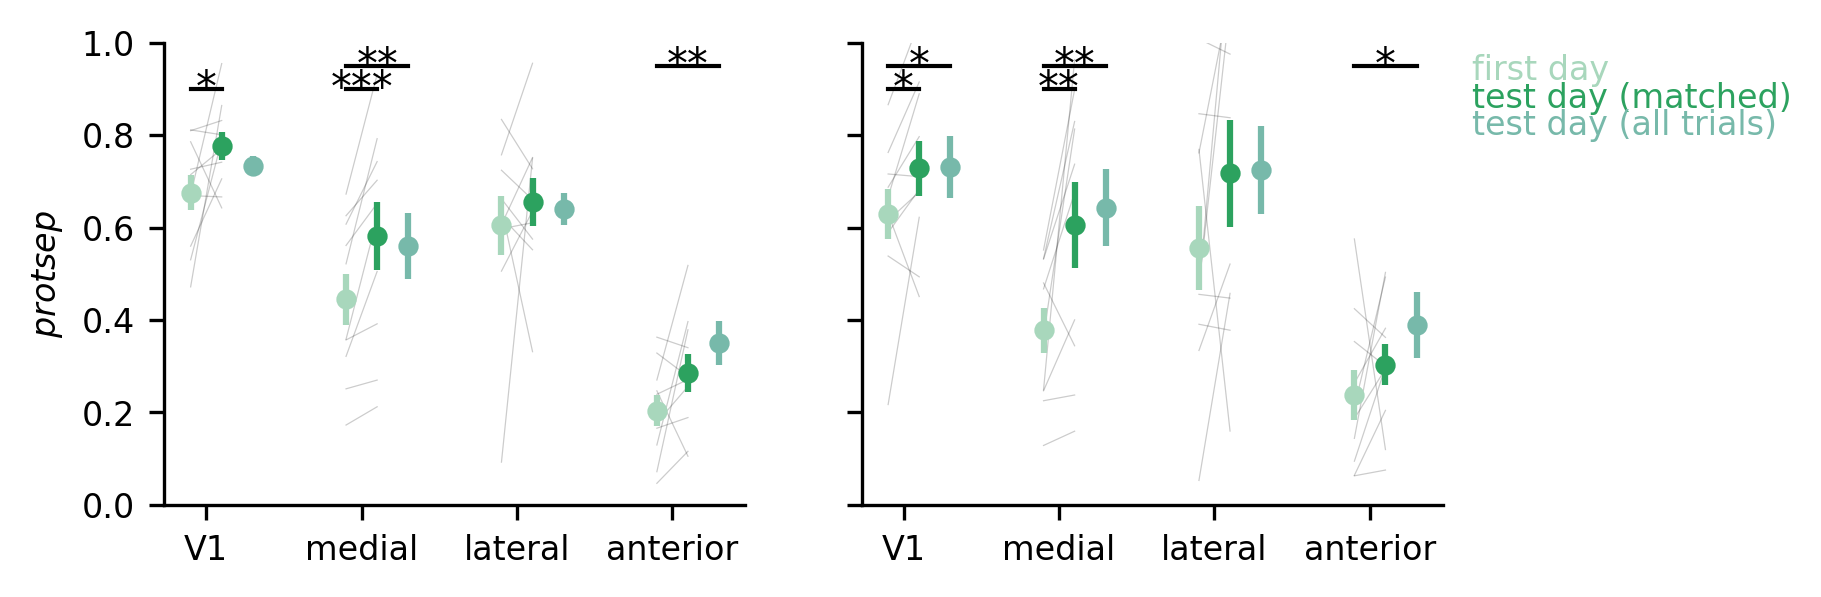

In [87]:
prot_distance = get_feature_fromdf("prot_distance", df_iindex_trial_dptsh)
from src import fig1
gis_first = prot_distance['first training']
gis_last = prot_distance['last training']
gis_last_m = prot_distance['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=.95, alternative=("greater", "greater"), ylabel='$prot sep$')
for a in ax.flatten():
    a.set_ylim(0,1)
sns.despine()

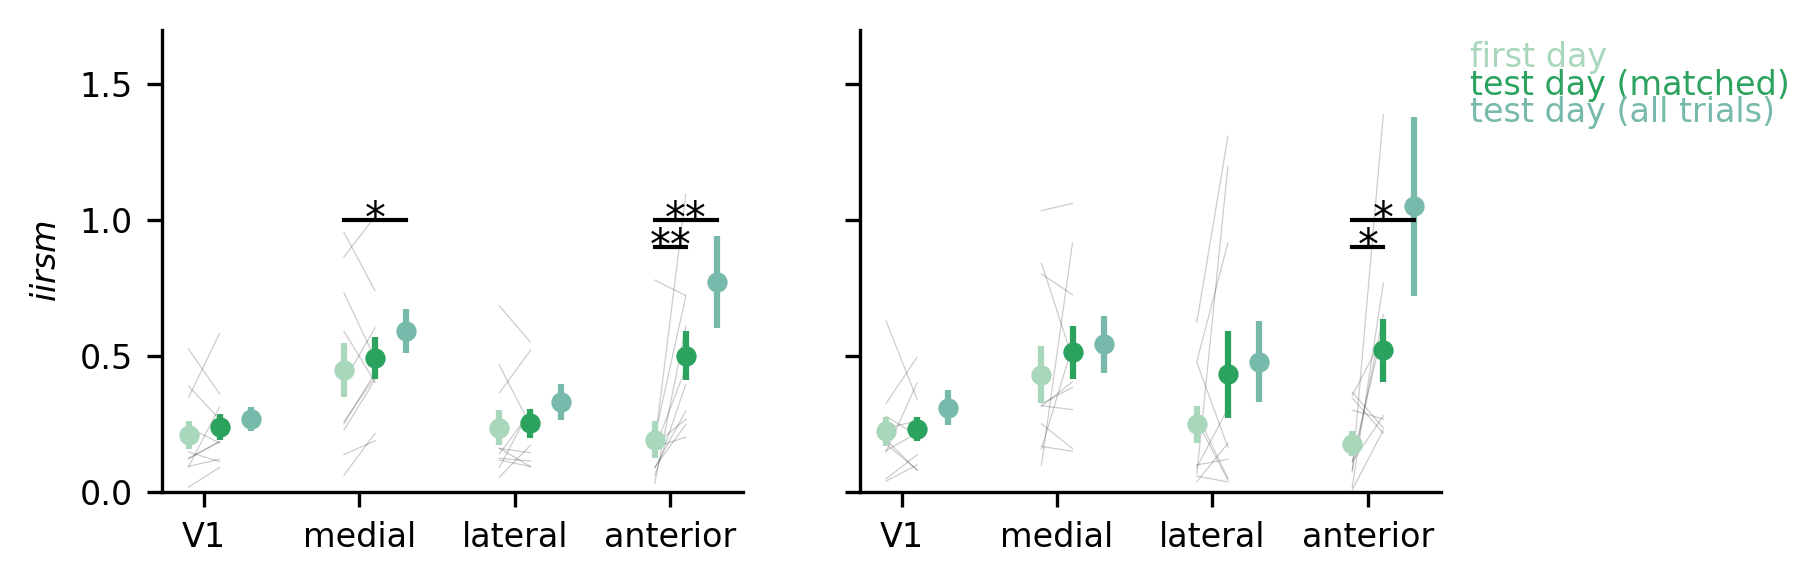

In [91]:
ii_rsm = get_feature_fromdf("ii_rsm", df_iindex_trial_dptsh)
from src import fig1
gis_first =ii_rsm['first training']
gis_last = ii_rsm['last training']
gis_last_m = ii_rsm['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=1, alternative=("greater", "greater"), ylabel='$ii rsm$')
for a in ax.flatten():
    a.set_ylim(0,1.7)
sns.despine()